#Actividad 05 ejercicio C

Supongan que forman parte del grupo de Machine Learning en un importante periódico en línea. Les han asignado la tarea de recomendar artículos similares al artículo que está leyendo actualmente un cliente. Es decir, dado un artículo, se debe encontrar artículos que tengan temas similares. Resuelvan el problema usando NMF y similitud de coseno o alguno similar.


In [ ]:
# LIBRERÍAS

from google.colab import drive

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# ===========================
# CONECTAR GOOGLE DRIVE
# ===========================

drive.mount('/content/drive')

RUTA_DATASET = "/content/drive/MyDrive/Aprendizaje Maquina/Datasets/BBC News Summary/News Articles"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# LEER LOS ARCHIVOS

datos = []

for categoria in sorted(os.listdir(RUTA_DATASET)):

    carpeta = os.path.join(RUTA_DATASET, categoria)

    if os.path.isdir(carpeta):

        for archivo in sorted(os.listdir(carpeta)):

            if archivo.endswith(".txt"):

                ruta_archivo = os.path.join(carpeta, archivo)

                with open(ruta_archivo,
                          "r",
                          encoding="latin-1") as f:

                    texto = f.read()

                datos.append({

                    "categoria": categoria,

                    "archivo": archivo,

                    "texto": texto

                })

df = pd.DataFrame(datos)

print("="*60)
print("DATASET CARGADO")
print("="*60)

display(df.head())

DATASET CARGADO


,categoria,archivo,texto
0,business,001.txt,Ad sales boost Time Warner profit\n\nQuarterly...
1,business,002.txt,Dollar gains on Greenspan speech\n\nThe dollar...
2,business,003.txt,Yukos unit buyer faces loan claim\n\nThe owner...
3,business,004.txt,High fuel prices hit BA's profits\n\nBritish A...
4,business,005.txt,Pernod takeover talk lifts Domecq\n\nShares in...



INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   categoria  2225 non-null   object
 1   archivo    2225 non-null   object
 2   texto      2225 non-null   object
dtypes: object(3)
memory usage: 52.3+ KB
None

Dimensiones: (2225, 3)

Valores nulos
categoria    0
archivo      0
texto        0
dtype: int64

Duplicados
0

Cantidad por categoría
categoria
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


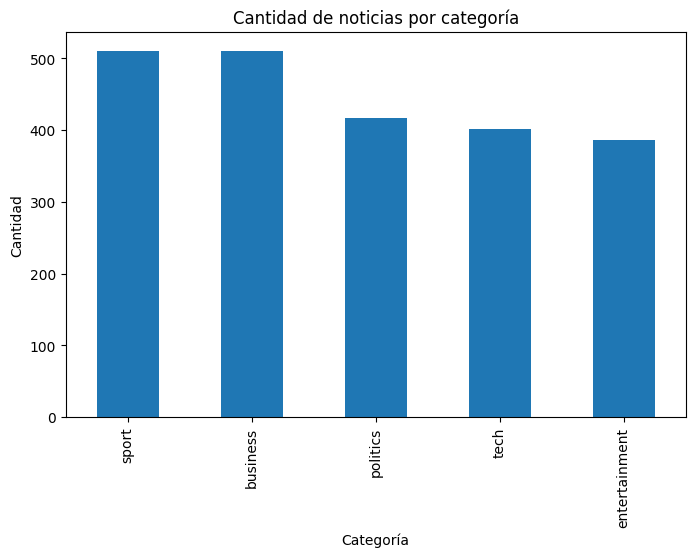

In [ ]:
# ============================================================
# EDA
# ============================================================

print("\n==============================")
print("INFORMACIÓN GENERAL")
print("==============================")

print(df.info())

print("\nDimensiones:", df.shape)

# ----------------------------

print("\nValores nulos")

print(df.isnull().sum())

# ----------------------------

print("\nDuplicados")

print(df.duplicated().sum())

# ----------------------------

print("\nCantidad por categoría")

print(df["categoria"].value_counts())

# ============================================================
# GRÁFICO CATEGORÍAS
# ============================================================

plt.figure(figsize=(8,5))

df["categoria"].value_counts().plot(kind="bar")

plt.title("Cantidad de noticias por categoría")

plt.xlabel("Categoría")

plt.ylabel("Cantidad")

plt.show()


Estadísticas longitud
count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: num_palabras, dtype: float64


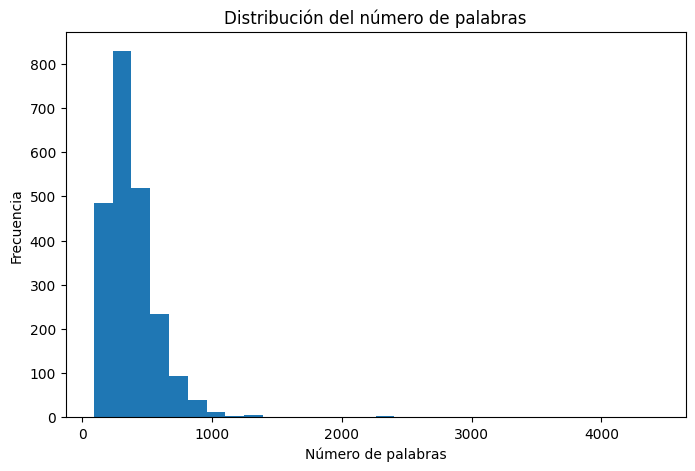

In [ ]:
# ============================================================
# LONGITUD DEL TEXTO
# ============================================================

df["num_palabras"] = df["texto"].apply(lambda x: len(x.split()))

print("\nEstadísticas longitud")

print(df["num_palabras"].describe())

# ----------------------------

plt.figure(figsize=(8,5))

plt.hist(df["num_palabras"], bins=30)

plt.title("Distribución del número de palabras")

plt.xlabel("Número de palabras")

plt.ylabel("Frecuencia")

plt.show()

<Figure size 900x500 with 0 Axes>

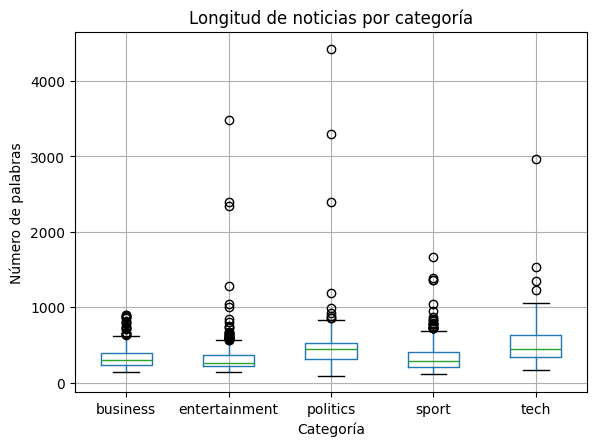

In [ ]:
# ============================================================
# BOXPLOT
# ============================================================

plt.figure(figsize=(9,5))

df.boxplot(column="num_palabras", by="categoria")

plt.title("Longitud de noticias por categoría")

plt.suptitle("")

plt.xlabel("Categoría")

plt.ylabel("Número de palabras")

plt.show()

In [ ]:
# ============================================================
# NOTICIAS MÁS LARGAS
# ============================================================

print("\nCinco noticias más largas")

display(

df.sort_values(

    "num_palabras",

    ascending=False

)[["categoria","archivo","num_palabras"]].head()

)


Cinco noticias más largas


,categoria,archivo,num_palabras
1185,politics,290.txt,4432
762,entertainment,253.txt,3482
1275,politics,380.txt,3295
2224,tech,401.txt,2969
1188,politics,293.txt,2393


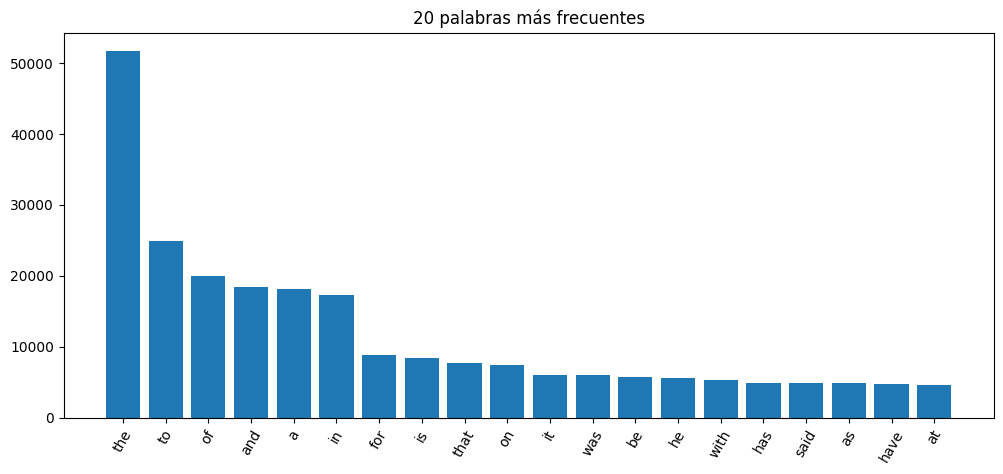

In [ ]:
# ============================================================
# PALABRAS MÁS FRECUENTES
# ============================================================

texto_total = " ".join(df["texto"]).lower()

palabras = texto_total.split()

conteo = Counter(palabras)

top20 = conteo.most_common(20)

palabras = [x[0] for x in top20]

frecuencia = [x[1] for x in top20]

plt.figure(figsize=(12,5))

plt.bar(palabras, frecuencia)

plt.xticks(rotation=60)

plt.title("20 palabras más frecuentes")

plt.show()

In [ ]:
# ============================================================
# TF-IDF
# ============================================================

print("\nConstruyendo matriz TF-IDF...")

vectorizer = TfidfVectorizer(

    stop_words="english",

    max_features=5000,

    min_df=2

)

X = vectorizer.fit_transform(df["texto"])

print("Dimensión matriz TF-IDF:", X.shape)


Construyendo matriz TF-IDF...
Dimensión matriz TF-IDF: (2225, 5000)


In [ ]:
# ============================================================
# NMF
# ============================================================

print("\nEntrenando NMF...")

nmf = NMF(

    n_components=5,

    random_state=42

)

W = nmf.fit_transform(X)

H = nmf.components_

print("Modelo entrenado correctamente.")


Entrenando NMF...
Modelo entrenado correctamente.


In [ ]:
# ============================================================
# TEMAS DESCUBIERTOS
# ============================================================

print("\nTEMAS ENCONTRADOS\n")

feature_names = vectorizer.get_feature_names_out()

for i, tema in enumerate(H):

    print("="*50)

    print("Tema", i+1)

    indices = tema.argsort()[-10:]

    palabras = [feature_names[j] for j in indices[::-1]]

    print(palabras)


TEMAS ENCONTRADOS

Tema 1
['england', 'game', 'win', 'wales', 'cup', 'ireland', 'said', 'play', 'team', 'match']
Tema 2
['mr', 'labour', 'election', 'blair', 'brown', 'party', 'said', 'government', 'howard', 'minister']
Tema 3
['growth', 'economy', 'said', 'year', 'sales', 'bank', 'economic', 'oil', 'market', '2004']
Tema 4
['film', 'best', 'awards', 'award', 'actor', 'oscar', 'festival', 'actress', 'films', 'won']
Tema 5
['mobile', 'people', 'music', 'said', 'digital', 'technology', 'phone', 'users', 'broadband', 'software']


In [ ]:
# ============================================================
# SIMILITUD
# ============================================================

print("\nCalculando similitud...")

similaridad = cosine_similarity(W)

# ============================================================
# RECOMENDADOR
# ============================================================

def recomendar(indice, top=5):

    print("="*80)

    print("ARTÍCULO CONSULTADO")

    print("="*80)

    print("Categoría:", df.iloc[indice]["categoria"])

    print("Archivo:", df.iloc[indice]["archivo"])

    print()

    print(df.iloc[indice]["texto"][:800])

    print("\n")

    similares = list(enumerate(similaridad[indice]))

    similares = sorted(

        similares,

        key=lambda x:x[1],

        reverse=True

    )

    contador = 0

    print("="*80)

    print("ARTÍCULOS RECOMENDADOS")

    print("="*80)

    for i, score in similares:

        if i != indice:

            print("\n")

            print("-"*60)

            print("Similitud:", round(score,4))

            print("Categoría:", df.iloc[i]["categoria"])

            print("Archivo:", df.iloc[i]["archivo"])

            print()

            print(df.iloc[i]["texto"][:350])

            contador += 1

            if contador == top:

                break


Calculando similitud...


In [ ]:
# ============================================================
# EJEMPLO
# ============================================================

print("\n\nEjemplo de recomendación\n")

recomendar(1000)



Ejemplo de recomendación

ARTÍCULO CONSULTADO
Categoría: politics
Archivo: 105.txt

Muslim police stops 'more likely'

UK Muslims should accept that people of Islamic appearance are more likely to be stopped and searched by police, a Home Office minister has said.

Hazel Blears said innocent Muslims would be targeted because of the search for Islamic extremists. Qualifications for religious leaders to enter the UK could also be made tougher, she told a Commons inquiry. Her comments have been described as "irresponsible" and "outrageous" by the Islamic Human Rights Commission (IHRC).

"The threat is most likely to come from those people associated with an extreme form of Islam, or who are falsely hiding behind Islam," the Salford MP told the Commons home affairs committee.

"It means that some of our counter-terrorism powers will be disproportionately experienced by the Mu


ARTÍCULOS RECOMENDADOS


------------------------------------------------------------
Similitud: 0.998
Categorí